## Import

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import torch
import matplotlib.pyplot as plt


device = 'cuda:1'

%load_ext autoreload
%autoreload 2

## Experiment settings

In [2]:
mi_level = "high"
mi_array = {'low':1, 'mid':3, 'high':7, 'very_high':9}
latent = False

mi = mi_array[mi_level]

## Data generation

image size torch.Size([10000, 16, 16]) torch.Size([10000, 16, 16])
data size torch.Size([10000, 256]) torch.Size([10000, 256])


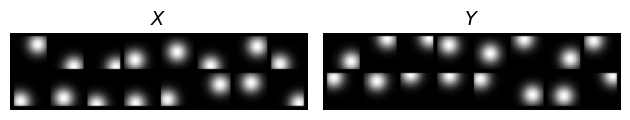

In [16]:
from datasets.image import image_dataset

X, Y = image_dataset.generate_gaussian_plot(mi=mi, n_samples=10000, device=device)

n, d = X.size()[0], 2*X.size()[1]

image_dataset.visualize_images(X, Y, 'results/images/gaussian_medium.png')

## Dimensionality reduction

In [10]:
from compression.autoencoder import Autoencoder


# [A]. Train autoencoders to compress data (one per side; the AE is single-branch,
#      so X and Y are compressed independently -> MI between the two sides is preserved)
if not os.path.isfile(f'results/images/gaussian_ae_X_{mi_level}.npy'):
    print('compression does not exist; train autoencoder')

    X, Y = X.to(device).float(), Y.to(device).float()

    ae_x = Autoencoder(x_dim=d//2, latent_dim=8)
    ae_y = Autoencoder(x_dim=d//2, latent_dim=8)
    ae_x.to(device); ae_y.to(device)
    ae_x.learn(X)
    ae_y.learn(Y)

    XX, YY = ae_x.encode(X).clone().detach(), ae_y.encode(Y).clone().detach()

    os.makedirs('results/images', exist_ok=True)
    np.save(f'results/images/gaussian_ae_X_{mi_level}.npy', XX.detach().cpu().numpy())
    np.save(f'results/images/gaussian_ae_Y_{mi_level}.npy', YY.detach().cpu().numpy())

# [B]. File exist; load previous compression
else:
    print('compression already exist; loading .npy files')

    XX = np.load(f'results/images/gaussian_ae_X_{mi_level}.npy', allow_pickle=True)
    YY = np.load(f'results/images/gaussian_ae_Y_{mi_level}.npy', allow_pickle=True)
    XX, YY = torch.Tensor(XX).clone().detach().to(device), torch.Tensor(YY).clone().detach().to(device)

n, d = torch.cat([XX, YY], dim=1).size()

XX, YY = XX[0:5000], YY[0:5000]

compression already exist; loading .npy files


## MI estimation

In [11]:
class Hyperparams(object):
    def __init__(self): 
        self.lr = 5e-4
        self.bs = 500
        self.wd = 1e-5
        self.max_iteration = 1250
        
hyperparams=Hyperparams()

architecture_critic = [d, 500, 500, 500, 1]

In [12]:
## Mutual information neural diffusion estimate (MINDE)
from estimators.MINDE import MINDE

hyperparams.t_patience = 500
hyperparams.dim = d//2
hyperparams.device = device
hyperparams.importance_sampling = True

estimator = MINDE(hyperparams)

estimator.to(device)
estimator.learn(XX, YY)

print('true MI:', mi)
print('est MI:', estimator.MI(XX, YY))

use ema: True bs: 500
finished: t= 0 loss= 1.4994268417358398 loss val= 1.4410539865493774 best val loss= 1.4410539865493774 best t= 0
finished: t= 63 loss= 0.9817826151847839 loss val= 0.9611495137214661 best val loss= 0.9055545926094055 best t= 54
finished: t= 126 loss= 0.9012219905853271 loss val= 0.8993495106697083 best val loss= 0.7526949644088745 best t= 86
finished: t= 189 loss= 0.8534602522850037 loss val= 0.804165244102478 best val loss= 0.697175920009613 best t= 184
finished: t= 252 loss= 0.8839210867881775 loss val= 0.7487069964408875 best val loss= 0.697175920009613 best t= 184
finished: t= 315 loss= 0.7356066703796387 loss val= 0.9880684018135071 best val loss= 0.6494874358177185 best t= 305
finished: t= 378 loss= 0.7429771423339844 loss val= 0.7378062009811401 best val loss= 0.6494874358177185 best t= 305
finished: t= 441 loss= 0.8368303179740906 loss val= 0.7113478779792786 best val loss= 0.6494874358177185 best t= 305
finished: t= 504 loss= 0.7781374454498291 loss val= 

In [83]:
## Mutual information neural estimate (MINE)
from estimators.MINE import MINE

estimator = MINE(architecture_critic, hyperparams)
estimator.to(device)
estimator.learn(X, Y)


print('true MI:', mi)
print('est MI:', estimator.MI(X, Y))

finished: t= 0 loss= 0.006665322929620743 loss val= 0.005651412531733513 best val loss= 0.005651412531733513 best t= 0
finished: t= 63 loss= -1.536266803741455 loss val= -1.1214815378189087 best val loss= -1.3254250288009644 best t= 62
finished: t= 126 loss= -2.181079864501953 loss val= -1.224069356918335 best val loss= -1.4149119853973389 best t= 124
finished: t= 189 loss= -2.2925498485565186 loss val= -1.236750602722168 best val loss= -1.4149119853973389 best t= 124
finished: t= 252 loss= -2.2205886840820312 loss val= -1.2665491104125977 best val loss= -1.4149119853973389 best t= 124


true MI: 3
est MI: 2.107102632522583


In [38]:
## Neural adaptive MI estimate
from estimators.VCE import VCE

estimator = VCE(hyperparams)
estimator.to(device)
estimator.learn(XX, YY)

print('true MI:', mi)
print('est MI:', estimator.MI(XX, YY))

finished: t= 0 loss= 267.4931335449219 loss val= 255.98739624023438 best val loss= 255.98739624023438 best t= 0
finished: t= 126 loss= 12.668143272399902 loss val= 11.099580764770508 best val loss= 9.87479305267334 best t= 92
finished: t= 252 loss= 12.596970558166504 loss val= 11.84226131439209 best val loss= 9.202648162841797 best t= 173
finished: t= 378 loss= 12.874719619750977 loss val= 11.500920295715332 best val loss= 8.386524200439453 best t= 347
finished: t= 504 loss= 12.547072410583496 loss val= 12.066286087036133 best val loss= 8.386524200439453 best t= 347


finished: t= 0 loss= 242.49545288085938 loss val= 231.03408813476562 best val loss= 231.03408813476562 best t= 0
finished: t= 126 loss= 11.600472450256348 loss val= 12.264055252075195 best val loss= 10.656892776489258 best t= 121
finished: t= 252 loss= 10.827380180358887 loss val= 10.019007682800293 best val loss= 9.654779434204102 best t= 165
finished: t= 378 loss= 10.131500244140625 loss val= 11.661873817443848 best val

In [21]:
## MI estimate via flows
from estimators.MIENF import MIENF

estimator = MIENF(hyperparams)
estimator.to(device)
estimator.learn(XX, YY)

print('true MI:', mi)
print('est MI:', estimator.MI(XX, YY))

MIENF (K=1), joint learning True 

finished: t= 0 loss= 4976.65185546875 loss val= 5142.8974609375 best val loss= 5142.8974609375 best t= 0
finished: t= 101 loss= 22.87349510192871 loss val= 23.496681213378906 best val loss= 22.68903923034668 best t= 100
finished: t= 202 loss= 12.480026245117188 loss val= 13.199854850769043 best val loss= 12.79878044128418 best t= 198
finished: t= 303 loss= 8.96914005279541 loss val= 10.163406372070312 best val loss= 7.484122276306152 best t= 296
finished: t= 404 loss= 5.318650245666504 loss val= 4.963801860809326 best val loss= 3.2651877403259277 best t= 396
finished: t= 505 loss= 6.607476711273193 loss val= 3.0763683319091797 best val loss= 1.617323875427246 best t= 497
finished: t= 606 loss= -0.6650816202163696 loss val= 0.3562144339084625 best val loss= -0.9773702621459961 best t= 600
finished: t= 707 loss= 0.14143583178520203 loss val= 0.15328332781791687 best val loss= -2.308738946914673 best t= 695
finished: t= 808 loss= -1.595508098602295 loss 